# Breast Cancer Survival Prediction Using Clinical and Protein Expression Features

## Project Description

Breast cancer survival prediction is an important clinical problem because early identification of high-risk patients may help guide follow-up care and treatment planning. In this project, we use a breast cancer survival dataset from Kaggle that contains patient demographics, tumor characteristics, hormone receptor status, protein expression levels, surgery type, and survival status.

The goal of this project is to build machine learning models to predict whether a breast cancer patient was alive or dead at the last recorded visit. The outcome variable is `Patient_Status`, which is converted into a binary variable where Alive = 0 and Dead = 1.

## Research Question

Can clinical characteristics, tumor information, hormone receptor status, protein expression levels, and surgery type be used to predict breast cancer survival status?

In this project, we compare several machine learning models, including logistic regression, random forest, and neural network models, to evaluate their ability to classify patients as alive or dead.

### Load Packages

In [61]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

### Load Dataset with KaggleHub

In [62]:
!pip install kagglehub

import kagglehub

dataset_path = kagglehub.dataset_download(
    "kreeshrajani/breast-cancer-survival-dataset"
)

print("Dataset path:", dataset_path)
print("Files:", os.listdir(dataset_path))


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Dataset path: C:\Users\avicz\.cache\kagglehub\datasets\kreeshrajani\breast-cancer-survival-dataset\versions\1
Files: ['breast_cancer_survival.csv']


In [63]:
csv_files = [f for f in os.listdir(dataset_path) if f.endswith(".csv")]
file_path = os.path.join(dataset_path, csv_files[0])

df = pd.read_csv(file_path)

print("Loaded file:", file_path)
print("Shape:", df.shape)
df.head()

Loaded file: C:\Users\avicz\.cache\kagglehub\datasets\kreeshrajani\breast-cancer-survival-dataset\versions\1\breast_cancer_survival.csv
Shape: (334, 15)


,Age,Gender,Protein1,Protein2,Protein3,Protein4,Tumour_Stage,Histology,ER status,PR status,HER2 status,Surgery_type,Date_of_Surgery,Date_of_Last_Visit,Patient_Status
0,42,FEMALE,0.95256,2.15000,0.007972,-0.048340,II,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Other,20-May-18,26-Aug-18,Alive
1,54,FEMALE,0.00000,1.38020,-0.498030,-0.507320,II,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Other,26-Apr-18,25-Jan-19,Dead
2,63,FEMALE,-0.52303,1.76400,-0.370190,0.010815,II,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Lumpectomy,24-Aug-18,08-Apr-20,Alive
3,78,FEMALE,-0.87618,0.12943,-0.370380,0.132190,I,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Other,16-Nov-18,28-Jul-20,Alive
4,42,FEMALE,0.22611,1.74910,-0.543970,-0.390210,II,Infiltrating Ductal Carcinoma,Positive,Positive,Positive,Lumpectomy,12-Dec-18,05-Jan-19,Alive


In [64]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 334 entries, 0 to 333
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 334 non-null    int64  
 1   Gender              334 non-null    str    
 2   Protein1            334 non-null    float64
 3   Protein2            334 non-null    float64
 4   Protein3            334 non-null    float64
 5   Protein4            334 non-null    float64
 6   Tumour_Stage        334 non-null    str    
 7   Histology           334 non-null    str    
 8   ER status           334 non-null    str    
 9   PR status           334 non-null    str    
 10  HER2 status         334 non-null    str    
 11  Surgery_type        334 non-null    str    
 12  Date_of_Surgery     334 non-null    str    
 13  Date_of_Last_Visit  317 non-null    str    
 14  Patient_Status      321 non-null    str    
dtypes: float64(4), int64(1), str(10)
memory usage: 39.3 KB


In [65]:
df.isna().sum()

Age                    0
Gender                 0
Protein1               0
Protein2               0
Protein3               0
Protein4               0
Tumour_Stage           0
Histology              0
ER status              0
PR status              0
HER2 status            0
Surgery_type           0
Date_of_Surgery        0
Date_of_Last_Visit    17
Patient_Status        13
dtype: int64

In [66]:
df["Patient_Status"].value_counts()

Patient_Status
Alive    255
Dead      66
Name: count, dtype: int64

In [67]:
df["Patient_Status"].value_counts(normalize=True)

Patient_Status
Alive    0.794393
Dead     0.205607
Name: proportion, dtype: float64

In [68]:
# Drop rows with missing outcome
df_model = df.dropna(subset=["Patient_Status"]).copy()

# Convert survival status to binary outcome
df_model["death"] = df_model["Patient_Status"].map({
    "Alive": 0,
    "Dead": 1
})

print(df_model.shape)
print(df_model["death"].value_counts())
print(df_model["death"].value_counts(normalize=True))

(321, 16)
death
0    255
1     66
Name: count, dtype: int64
death
0    0.794393
1    0.205607
Name: proportion, dtype: float64


After removing 13 patients with missing survival status, 321 patients remained for modeling. Among these patients, 255 were alive and 66 were dead at the last recorded visit. Therefore, the death class represented about 20.6% of the analytic sample, indicating moderate class imbalance. Because death is the clinically important minority outcome, death was coded as the positive class.

### EDA

#### 1. Outcome Distribution

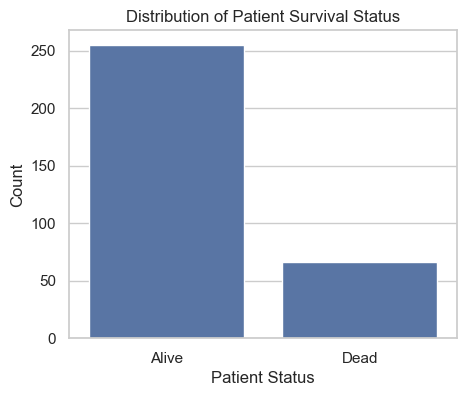

In [69]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df_model, x="Patient_Status")
plt.title("Distribution of Patient Survival Status")
plt.xlabel("Patient Status")
plt.ylabel("Count")
plt.show()

#### 2. Age by Survival Status

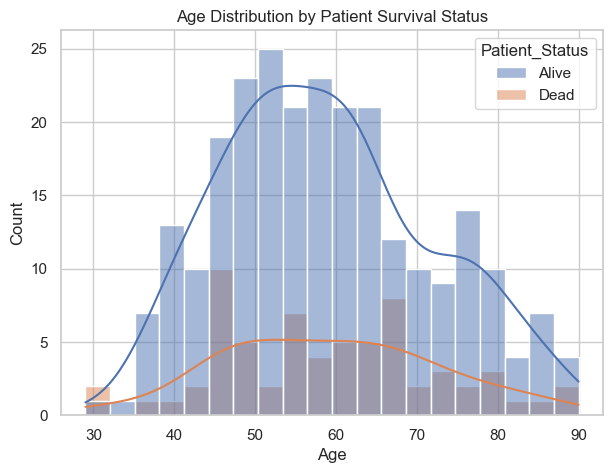

In [70]:
plt.figure(figsize=(7, 5))
sns.histplot(
    data=df_model,
    x="Age",
    hue="Patient_Status",
    kde=True,
    bins=20
)
plt.title("Age Distribution by Patient Survival Status")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

#### 3. Tumor Stage by Survival Status

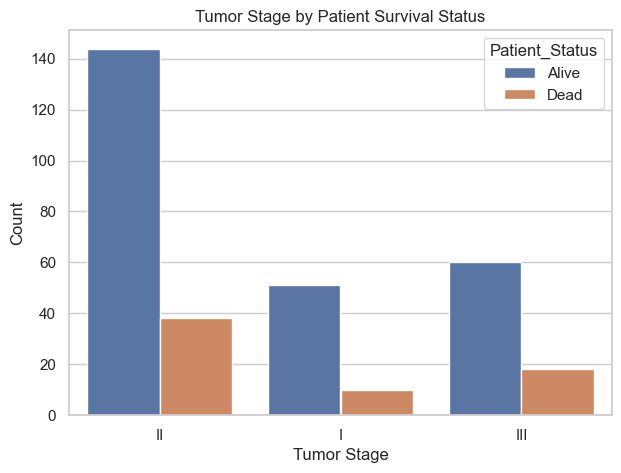

In [71]:
plt.figure(figsize=(7, 5))
sns.countplot(
    data=df_model,
    x="Tumour_Stage",
    hue="Patient_Status"
)
plt.title("Tumor Stage by Patient Survival Status")
plt.xlabel("Tumor Stage")
plt.ylabel("Count")
plt.show()

#### Protein Expression by Survival Status

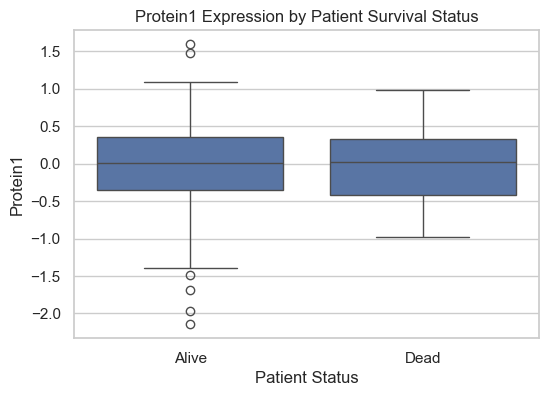

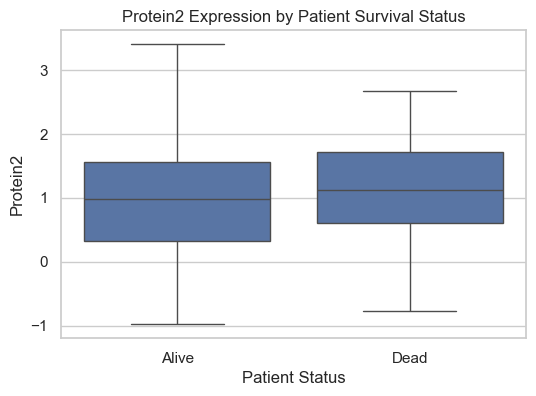

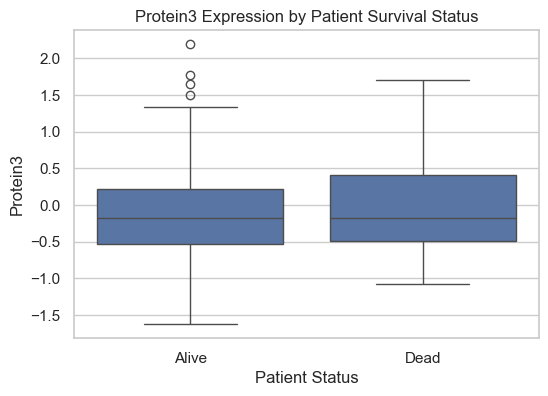

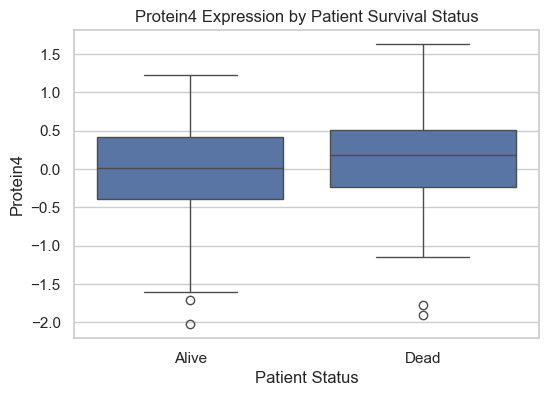

In [72]:
protein_cols = ["Protein1", "Protein2", "Protein3", "Protein4"]

for col in protein_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df_model, x="Patient_Status", y=col)
    plt.title(f"{col} Expression by Patient Survival Status")
    plt.xlabel("Patient Status")
    plt.ylabel(col)
    plt.show()

### Modeling Data

In [73]:
drop_cols = [
    "Patient_Status",
    "death",
    "Date_of_Surgery",
    "Date_of_Last_Visit"
]

X = df_model.drop(columns=drop_cols, errors="ignore")
y = df_model["death"]

print("Feature matrix shape:", X.shape)
print("Outcome shape:", y.shape)

X.head()

Feature matrix shape: (321, 12)
Outcome shape: (321,)


,Age,Gender,Protein1,Protein2,Protein3,Protein4,Tumour_Stage,Histology,ER status,PR status,HER2 status,Surgery_type
0,42,FEMALE,0.95256,2.15000,0.007972,-0.048340,II,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Other
1,54,FEMALE,0.00000,1.38020,-0.498030,-0.507320,II,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Other
2,63,FEMALE,-0.52303,1.76400,-0.370190,0.010815,II,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Lumpectomy
3,78,FEMALE,-0.87618,0.12943,-0.370380,0.132190,I,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Other
4,42,FEMALE,0.22611,1.74910,-0.543970,-0.390210,II,Infiltrating Ductal Carcinoma,Positive,Positive,Positive,Lumpectomy


#### Feature Types Check

In [74]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "str"]).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("Feature matrix shape:", X.shape)
print("Outcome shape:", y.shape)

Numeric features:
['Age', 'Protein1', 'Protein2', 'Protein3', 'Protein4']

Categorical features:
['Gender', 'Tumour_Stage', 'Histology', 'ER status', 'PR status', 'HER2 status', 'Surgery_type']
Feature matrix shape: (321, 12)
Outcome shape: (321,)


## Train-Test Split

The analytic dataset was split into training and test sets. A stratified split was used so that the proportion of alive and dead patients remained similar in both sets. This is important because the death outcome is the minority class.

In [75]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

print("\nTraining outcome distribution:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

print("\nTest outcome distribution:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True))

Training set shape: (240, 12)
Test set shape: (81, 12)

Training outcome distribution:
death
0    191
1     49
Name: count, dtype: int64
death
0    0.795833
1    0.204167
Name: proportion, dtype: float64

Test outcome distribution:
death
0    64
1    17
Name: count, dtype: int64
death
0    0.790123
1    0.209877
Name: proportion, dtype: float64


## Preprocessing Pipeline

Before fitting the models, numeric and categorical variables were preprocessed separately. Numeric variables were imputed using the median and standardized. Categorical variables were imputed using the most frequent category and one-hot encoded. These preprocessing steps were placed inside a pipeline to avoid data leakage from the test set.

In [76]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## Model Evaluation Metrics

Several metrics were used to evaluate model performance, including accuracy, precision, recall, specificity, F1 score, and ROC AUC. Because the clinical goal is to identify patients at higher risk of death, recall or sensitivity for the death class is especially important. However, precision and specificity are also considered because false positive predictions may lead to unnecessary concern or follow-up.

In [77]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

def evaluate_model(name, model, X_test, y_test):
    """
    Evaluate a fitted classification model on the test set.

    Parameters
    ----------
    name : str
        Name of the model.
    model : sklearn Pipeline
        Fitted model pipeline.
    X_test : pandas DataFrame
        Test feature matrix.
    y_test : pandas Series
        True test labels.

    Returns
    -------
    dict
        Dictionary containing model evaluation metrics.
    """
    y_pred = model.predict(X_test)
    
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_prob)
    else:
        roc_auc = np.nan
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    results = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall / Sensitivity": recall_score(y_test, y_pred, zero_division=0),
        "Specificity": tn / (tn + fp),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC AUC": roc_auc,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }
    
    print("\n" + name)
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))
    
    return results

## Model 1: Logistic Regression

Logistic regression was used as a baseline interpretable model. Because the death outcome is less common than the alive outcome, class weights were balanced to reduce the influence of class imbalance during model training.

In [78]:
from sklearn.linear_model import LogisticRegression

log_reg = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

log_reg.fit(X_train, y_train)

log_results = evaluate_model(
    "Logistic Regression",
    log_reg,
    X_test,
    y_test
)


Logistic Regression
Confusion Matrix:
[[36 28]
 [ 8  9]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.56      0.67        64
           1       0.24      0.53      0.33        17

    accuracy                           0.56        81
   macro avg       0.53      0.55      0.50        81
weighted avg       0.70      0.56      0.60        81



## Model 2: Random Forest

Random forest was used as a nonlinear machine learning model. Unlike logistic regression, random forest can capture nonlinear relationships and interactions between predictors. Class weights were also balanced to account for the minority death class.

In [79]:
from sklearn.ensemble import RandomForestClassifier

rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ))
])

rf.fit(X_train, y_train)

rf_results = evaluate_model(
    "Random Forest",
    rf,
    X_test,
    y_test
)


Random Forest
Confusion Matrix:
[[62  2]
 [15  2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.97      0.88        64
           1       0.50      0.12      0.19        17

    accuracy                           0.79        81
   macro avg       0.65      0.54      0.53        81
weighted avg       0.74      0.79      0.73        81



## Model 3: XGBoost

XGBoost was included as an additional gradient boosting model. Compared with random forest, XGBoost builds trees sequentially, where each new tree attempts to correct errors made by previous trees. This can improve predictive performance on structured tabular data. Because the death class is less common than the alive class, class imbalance was handled using the `scale_pos_weight` parameter.

In [80]:
# Calculate class weight for XGBoost
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Negative count:", negative_count)
print("Positive count:", positive_count)
print("scale_pos_weight:", scale_pos_weight)

Negative count: 191
Positive count: 49
scale_pos_weight: 3.8979591836734695


In [81]:
xgb = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=42
    ))
])

xgb.fit(X_train, y_train)

xgb_results = evaluate_model(
    "XGBoost",
    xgb,
    X_test,
    y_test
)


XGBoost
Confusion Matrix:
[[55  9]
 [15  2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.86      0.82        64
           1       0.18      0.12      0.14        17

    accuracy                           0.70        81
   macro avg       0.48      0.49      0.48        81
weighted avg       0.66      0.70      0.68        81



## Model 4: Neural Network

A neural network model was trained to evaluate whether a more flexible nonlinear model could improve prediction of breast cancer survival status. The model used two hidden layers with ReLU activation. Because neural networks can be sensitive to feature scale, numeric variables were standardized before model fitting.

In [82]:
from sklearn.neural_network import MLPClassifier

nn = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", MLPClassifier(
        hidden_layer_sizes=(32, 16),
        activation="relu",
        solver="adam",
        max_iter=2000,
        random_state=42
    ))
])

nn.fit(X_train, y_train)

nn_results = evaluate_model(
    "Neural Network",
    nn,
    X_test,
    y_test
)


Neural Network
Confusion Matrix:
[[59  5]
 [13  4]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.92      0.87        64
           1       0.44      0.24      0.31        17

    accuracy                           0.78        81
   macro avg       0.63      0.58      0.59        81
weighted avg       0.74      0.78      0.75        81



## Model Performance Comparison

The three models were compared on the same held-out test set. The results table summarizes accuracy, precision, recall, specificity, F1 score, ROC AUC, and the confusion matrix counts for each model.

In [83]:
results_df = pd.DataFrame([
    log_results,
    rf_results,
    xgb_results,
    nn_results
])

results_df.round(3)

,Model,Accuracy,Precision,Recall / Sensitivity,Specificity,F1 Score,ROC AUC,TN,FP,FN,TP
0,Logistic Regression,0.556,0.243,0.529,0.562,0.333,0.499,36,28,8,9
1,Random Forest,0.790,0.500,0.118,0.969,0.190,0.586,62,2,15,2
2,XGBoost,0.704,0.182,0.118,0.859,0.143,0.509,55,9,15,2
3,Neural Network,0.778,0.444,0.235,0.922,0.308,0.646,59,5,13,4


## Confusion Matrix Interpretation

The confusion matrices show that most models were better at predicting the majority class, Alive, than the minority class, Dead. Random forest correctly classified 62 of 64 alive patients but only correctly identified 2 of 17 dead patients. XGBoost also identified only 2 of 17 dead patients. The neural network performed slightly better for the death class, identifying 4 of 17 dead patients.

Logistic regression had the highest number of true positives, correctly identifying 9 of 17 dead patients. However, it also incorrectly classified 28 alive patients as dead. This trade-off suggests that logistic regression was more aggressive in predicting death, while random forest and XGBoost were more conservative and tended to predict patients as alive.

## Model Performance Results

The four models showed different trade-offs between overall accuracy and sensitivity for the death class. Logistic regression had the lowest accuracy at 0.556, but it achieved the highest recall for death at 0.529. This means that logistic regression identified 9 out of 17 patients who died, but it also produced many false positives.

Random forest had the highest accuracy at 0.790 and very high specificity at 0.969, but its recall for death was only 0.118. This means that although random forest performed well in identifying patients who were alive, it missed most patients who died. XGBoost showed a similar limitation, with recall of only 0.118 for the death class. The neural network achieved accuracy of 0.778 and had a slightly better recall than random forest and XGBoost, but it still detected only 4 out of 17 death cases.

Overall, logistic regression was the most sensitive model for identifying death cases, while random forest and neural network had better overall accuracy. Because the clinical goal is to identify patients at higher risk of death, recall is especially important. Therefore, logistic regression may be more useful as a screening model, although its low precision and high false positive rate should be considered.

## Threshold Tuning

In [84]:
from sklearn.metrics import precision_recall_curve

def evaluate_with_threshold(name, model, X_test, y_test, threshold=0.30):
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    results = {
        "Model": name,
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall / Sensitivity": recall_score(y_test, y_pred),
        "Specificity": tn / (tn + fp),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_prob),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

    print(name)
    print("Confusion Matrix:")
    print(cm)
    print(classification_report(y_test, y_pred, zero_division=0))

    return results

In [85]:
log_tuned = evaluate_with_threshold(
    "Logistic Regression Tuned Threshold",
    log_reg,
    X_test,
    y_test,
    threshold=0.30
)

rf_tuned = evaluate_with_threshold(
    "Random Forest Tuned Threshold",
    rf,
    X_test,
    y_test,
    threshold=0.30
)

xgb_tuned = evaluate_with_threshold(
    "XGBoost Tuned Threshold",
    xgb,
    X_test,
    y_test,
    threshold=0.30
)

nn_tuned = evaluate_with_threshold(
    "Neural Network Tuned Threshold",
    nn,
    X_test,
    y_test,
    threshold=0.30
)

tuned_results_df = pd.DataFrame([
    log_tuned,
    rf_tuned,
    xgb_tuned,
    nn_tuned
])

tuned_results_df.round(3)

Logistic Regression Tuned Threshold
Confusion Matrix:
[[ 5 59]
 [ 3 14]]
              precision    recall  f1-score   support

           0       0.62      0.08      0.14        64
           1       0.19      0.82      0.31        17

    accuracy                           0.23        81
   macro avg       0.41      0.45      0.23        81
weighted avg       0.53      0.23      0.18        81

Random Forest Tuned Threshold
Confusion Matrix:
[[28 36]
 [ 6 11]]
              precision    recall  f1-score   support

           0       0.82      0.44      0.57        64
           1       0.23      0.65      0.34        17

    accuracy                           0.48        81
   macro avg       0.53      0.54      0.46        81
weighted avg       0.70      0.48      0.52        81

XGBoost Tuned Threshold
Confusion Matrix:
[[48 16]
 [10  7]]
              precision    recall  f1-score   support

           0       0.83      0.75      0.79        64
           1       0.30      0.41   

,Model,Threshold,Accuracy,Precision,Recall / Sensitivity,Specificity,F1 Score,ROC AUC,TN,FP,FN,TP
0,Logistic Regression Tuned Threshold,0.3,0.235,0.192,0.824,0.078,0.311,0.499,5,59,3,14
1,Random Forest Tuned Threshold,0.3,0.481,0.234,0.647,0.438,0.344,0.586,28,36,6,11
2,XGBoost Tuned Threshold,0.3,0.679,0.304,0.412,0.750,0.350,0.509,48,16,10,7
3,Neural Network Tuned Threshold,0.3,0.778,0.462,0.353,0.891,0.400,0.646,57,7,11,6


In [86]:
thresholds = [0.2, 0.3, 0.4, 0.5]

threshold_results = []

for model_name, model in [
    ("Logistic Regression", log_reg),
    ("Random Forest", rf),
    ("XGBoost", xgb),
    ("Neural Network", nn)
]:
    for t in thresholds:
        y_prob = model.predict_proba(X_test)[:, 1]
        y_pred = (y_prob >= t).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

        threshold_results.append({
            "Model": model_name,
            "Threshold": t,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, zero_division=0),
            "Recall": recall_score(y_test, y_pred),
            "Specificity": tn / (tn + fp),
            "F1": f1_score(y_test, y_pred),
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp
        })

threshold_df = pd.DataFrame(threshold_results)
threshold_df.round(3)

,Model,Threshold,Accuracy,Precision,Recall,Specificity,F1,TN,FP,FN,TP
0,Logistic Regression,0.2,0.222,0.212,1.000,0.016,0.351,1,63,0,17
1,Logistic Regression,0.3,0.235,0.192,0.824,0.078,0.311,5,59,3,14
2,Logistic Regression,0.4,0.346,0.219,0.824,0.219,0.346,14,50,3,14
3,Logistic Regression,0.5,0.556,0.243,0.529,0.562,0.333,36,28,8,9
4,Random Forest,0.2,0.259,0.213,0.941,0.078,0.348,5,59,1,16
5,Random Forest,0.3,0.481,0.234,0.647,0.438,0.344,28,36,6,11
6,Random Forest,0.4,0.667,0.273,0.353,0.750,0.308,48,16,11,6
7,Random Forest,0.5,0.778,0.400,0.118,0.953,0.182,61,3,15,2
8,XGBoost,0.2,0.630,0.276,0.471,0.672,0.348,43,21,9,8
9,XGBoost,0.3,0.679,0.304,0.412,0.750,0.350,48,16,10,7


In [87]:
threshold_df.sort_values("F1", ascending=False).round(3)

,Model,Threshold,Accuracy,Precision,Recall,Specificity,F1,TN,FP,FN,TP
14,Neural Network,0.4,0.790,0.500,0.353,0.906,0.414,58,6,11,6
13,Neural Network,0.3,0.778,0.462,0.353,0.891,0.400,57,7,11,6
12,Neural Network,0.2,0.753,0.400,0.353,0.859,0.375,55,9,11,6
0,Logistic Regression,0.2,0.222,0.212,1.000,0.016,0.351,1,63,0,17
9,XGBoost,0.3,0.679,0.304,0.412,0.750,0.350,48,16,10,7
4,Random Forest,0.2,0.259,0.213,0.941,0.078,0.348,5,59,1,16
8,XGBoost,0.2,0.630,0.276,0.471,0.672,0.348,43,21,9,8
2,Logistic Regression,0.4,0.346,0.219,0.824,0.219,0.346,14,50,3,14
5,Random Forest,0.3,0.481,0.234,0.647,0.438,0.344,28,36,6,11
3,Logistic Regression,0.5,0.556,0.243,0.529,0.562,0.333,36,28,8,9


Threshold tuning showed that lowering the classification threshold increased recall for some models, but it also created a clear trade-off with specificity. For example, logistic regression at threshold 0.20 achieved perfect recall, correctly identifying all 17 death cases, but it also produced 63 false positives and had a specificity of only 0.016. This indicates that the model over-classified patients as dead and would not be clinically practical.

Among all threshold settings, the neural network model with a threshold of 0.40 achieved the highest F1 score. This model had an accuracy of 0.790, precision of 0.500, recall of 0.353, specificity of 0.906, and F1 score of 0.414. Although its recall was lower than logistic regression and random forest at lower thresholds, it provided the most balanced performance by maintaining relatively high specificity while still identifying some death cases. Therefore, the neural network model with a 0.40 threshold was selected as the final model.

## Confusion Matrix

In [88]:
best_model = nn
best_threshold = 0.4

y_prob_best = best_model.predict_proba(X_test)[:, 1]
y_pred_best = (y_prob_best >= best_threshold).astype(int)

cm_best = confusion_matrix(y_test, y_pred_best)

print("Final Selected Model: Neural Network")
print("Threshold:", best_threshold)
print("Confusion Matrix:")
print(cm_best)
print(classification_report(y_test, y_pred_best, zero_division=0))

Final Selected Model: Neural Network
Threshold: 0.4
Confusion Matrix:
[[58  6]
 [11  6]]
              precision    recall  f1-score   support

           0       0.84      0.91      0.87        64
           1       0.50      0.35      0.41        17

    accuracy                           0.79        81
   macro avg       0.67      0.63      0.64        81
weighted avg       0.77      0.79      0.78        81



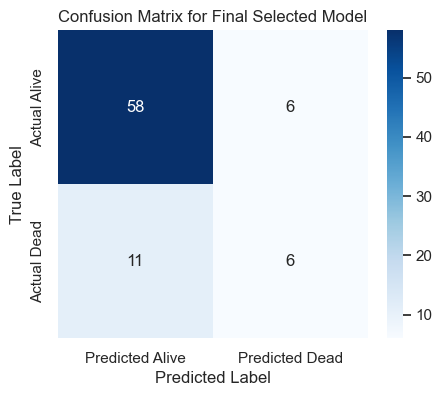

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_best,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Alive", "Predicted Dead"],
    yticklabels=["Actual Alive", "Actual Dead"]
)
plt.title("Confusion Matrix for Final Selected Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## Random Forest Feature Importance

To better understand which variables contributed most to the random forest predictions, feature importance values were extracted from the fitted random forest model. These values indicate how much each feature contributed to reducing impurity across the trees. However, feature importance should be interpreted cautiously because it does not imply causality.

In [90]:
feature_names = rf.named_steps["preprocessor"].get_feature_names_out()
importances = rf.named_steps["classifier"].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

feature_importance_df.head(15)

,Feature,Importance
4,num__Protein4,0.172317
1,num__Protein1,0.161757
2,num__Protein2,0.155621
0,num__Age,0.149783
3,num__Protein3,0.139611
17,cat__Surgery_type_Lumpectomy,0.022028
20,cat__Surgery_type_Simple Mastectomy,0.021839
9,cat__Tumour_Stage_III,0.021761
8,cat__Tumour_Stage_II,0.021473
18,cat__Surgery_type_Modified Radical Mastectomy,0.021332


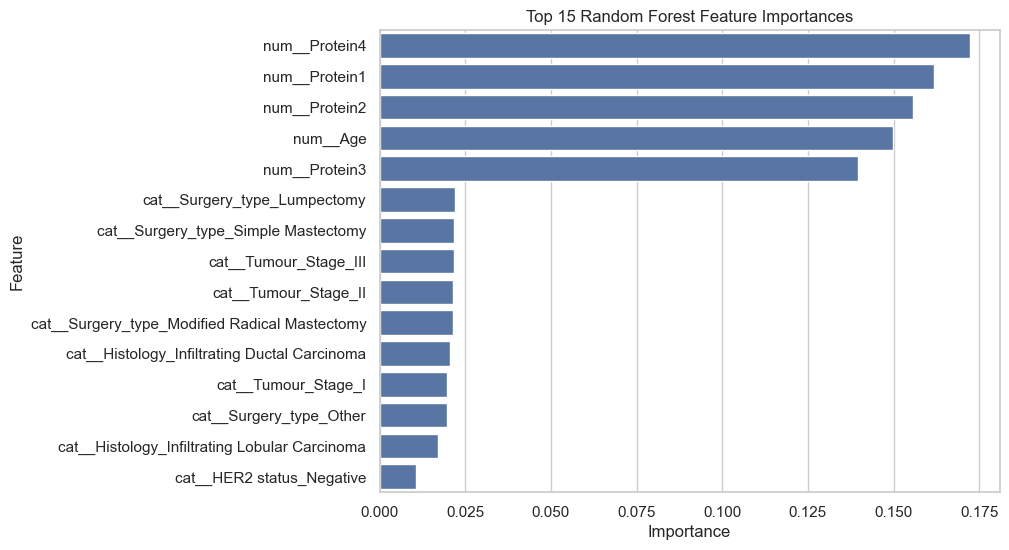

In [91]:
plt.figure(figsize=(8, 6))
sns.barplot(
    data=feature_importance_df.head(15),
    x="Importance",
    y="Feature"
)
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## XGBoost Feature Importance

Feature importance from the XGBoost model was also examined to identify predictors that contributed most to the boosted tree model. These importance values should be interpreted as model-based summaries rather than causal effects.

In [92]:
xgb_feature_names = xgb.named_steps["preprocessor"].get_feature_names_out()
xgb_importances = xgb.named_steps["classifier"].feature_importances_

xgb_feature_importance_df = pd.DataFrame({
    "Feature": xgb_feature_names,
    "Importance": xgb_importances
}).sort_values("Importance", ascending=False)

xgb_feature_importance_df.head(15)

,Feature,Importance
16,cat__HER2 status_Positive,0.102082
5,cat__Gender_FEMALE,0.080368
20,cat__Surgery_type_Simple Mastectomy,0.066645
7,cat__Tumour_Stage_I,0.062871
15,cat__HER2 status_Negative,0.060956
17,cat__Surgery_type_Lumpectomy,0.059404
4,num__Protein4,0.058954
1,num__Protein1,0.056511
9,cat__Tumour_Stage_III,0.052084
2,num__Protein2,0.051307


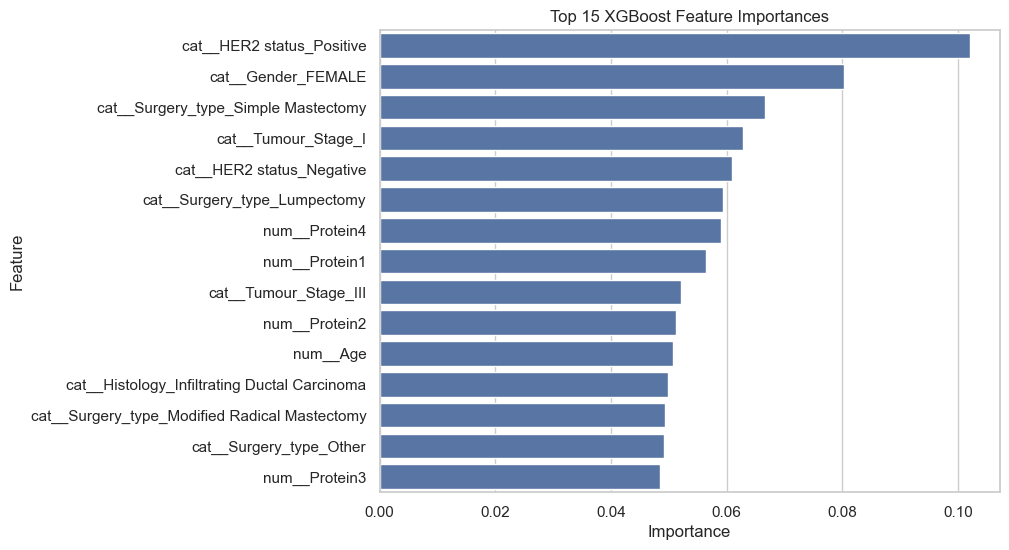

In [93]:
plt.figure(figsize=(8, 6))
sns.barplot(
    data=xgb_feature_importance_df.head(15),
    x="Importance",
    y="Feature"
)
plt.title("Top 15 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

The XGBoost feature importance results showed that categorical clinical features had relatively high importance. The most important feature was HER2-positive status, followed by female gender, simple mastectomy, tumor stage I, HER2-negative status, and lumpectomy. Protein expression variables such as Protein4, Protein1, Protein2, and Protein3 also appeared among the top predictors, but they were not ranked as high as in the random forest model.

Compared with random forest, XGBoost placed more emphasis on categorical variables such as HER2 status, surgery type, gender, and tumor stage. In contrast, random forest ranked the protein expression variables and age as the most important predictors. This suggests that the two tree-based models used different patterns in the data when making predictions. However, these feature importance values are model-dependent and should not be interpreted as causal relationships.

## Comparison of Random Forest and XGBoost Feature Importance

The two tree-based models produced different feature importance rankings. In the random forest model, the top predictors were mainly continuous variables, including Protein4, Protein1, Protein2, Age, and Protein3. In the XGBoost model, the top predictors were mostly categorical clinical variables, including HER2 status, gender, surgery type, and tumor stage.

This difference may reflect how the two algorithms learn from the data. Random forest builds many independent decision trees and averages their predictions, while XGBoost builds trees sequentially to correct previous errors. As a result, the models may rely on different variables even when trained on the same dataset. Because the dataset is small, these rankings should be interpreted cautiously.

## Conclusion

In conclusion, this project compared logistic regression, random forest, XGBoost, and neural network models for predicting breast cancer survival status. The results showed that overall accuracy alone was not sufficient because death was the minority outcome. Some models achieved high recall after threshold tuning, but this came at the cost of many false positives and very low specificity.

The neural network model with a threshold of 0.40 was selected as the final model because it achieved the highest F1 score and provided the best balance between precision, recall, and specificity. However, the model still missed 11 of the 17 death cases in the test set, showing that prediction of mortality remains difficult with this small and imbalanced dataset. Future work should use a larger sample size, include survival time or follow-up information, apply external validation, and explore additional methods for handling class imbalance.

## Final Model Selection

After comparing all models and threshold settings, the neural network model with a classification threshold of 0.40 was selected as the final model. This model achieved the highest F1 score among all tested model-threshold combinations.

The final neural network model had an accuracy of 0.790, precision of 0.500, recall of 0.353, specificity of 0.906, and F1 score of 0.414. Its confusion matrix showed 58 true negatives, 6 false positives, 11 false negatives, and 6 true positives.

Although logistic regression and random forest achieved higher recall at lower thresholds, these models produced too many false positives and had very low specificity. For example, logistic regression at threshold 0.20 identified all death cases, but it incorrectly classified 63 alive patients as dead. Therefore, these models were less clinically practical despite their high recall.

Overall, the neural network with threshold 0.40 provided the most balanced trade-off between identifying death cases and avoiding excessive false positives.

## Discussion

This project compared logistic regression, random forest, XGBoost, and neural network models for predicting breast cancer survival status. Because death was the minority outcome in the dataset, accuracy alone was not a sufficient evaluation metric. A model could achieve relatively high accuracy by mostly predicting patients as alive, while still missing many patients who died.

Threshold tuning showed an important trade-off between sensitivity and specificity. Lowering the threshold increased recall for the death class, but it also increased the number of false positives. Logistic regression and random forest had high recall at low thresholds, but they classified too many alive patients as dead. In contrast, the neural network model with threshold 0.40 had the highest F1 score and maintained high specificity, making it the most balanced model in this analysis.

Feature importance results suggested that HER2 status, gender, surgery type, tumor stage, and protein-expression variables contributed to prediction. However, these results should not be interpreted as causal effects. They only show which variables were useful for prediction in the fitted models.

This analysis also has several limitations. First, the dataset was small, especially for the death outcome. The test set contained only 17 death cases, so model performance estimates may be unstable. Second, the dataset was imbalanced, which made it difficult for models to identify the minority class. Third, survival status was treated as a binary outcome, but survival time and follow-up duration were not modeled. Finally, the models were evaluated only on one train-test split, so external validation would be needed before applying the model to other patient populations.

## Conclusion

In conclusion, this project showed that machine learning models can be used to predict breast cancer survival status, but performance was limited by small sample size and class imbalance. Among all models and threshold settings, the neural network model with threshold 0.40 was selected as the final model because it achieved the highest F1 score and provided the best balance between precision, recall, and specificity.

However, the final model still missed 11 of the 17 death cases in the test set, showing that mortality prediction remains challenging with this dataset. Future work should use a larger dataset, include survival time or follow-up information, apply external validation, and consider additional approaches for handling class imbalance.

In [94]:
import joblib

final_model = nn
final_threshold = 0.40

joblib.dump(final_model, "breast_cancer_survival_model.pkl")
joblib.dump(final_threshold, "threshold.pkl")

print("Model and threshold saved successfully.")

Model and threshold saved successfully.
